# 01 Data Profile

Use this notebook to confirm the warehouse CSVs are shaped correctly before modeling.

This is the quality-control notebook for the project. It does not train models. It checks that the team and player warehouse tables loaded correctly, that row counts make sense, that missing values are visible early, and that team-game scoring distributions look reasonable before the modeling notebooks depend on them.


## Load Warehouse Tables

Read the two warehouse fact tables that everything else depends on:

- `fact_team_game.csv`: one row per team per game, used for rolling team features and standings.
- `fact_player_game.csv`: one row per player per game, used later to build player event weights.


In [1]:
from pathlib import Path
import os
import pandas as pd

# Resolve paths so the notebook works from either the repo root or the notebooks folder.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
WAREHOUSE = ROOT / 'warehouse'
# Keep matplotlib cache files inside the repo instead of the user profile.
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib'))
(ROOT / '.matplotlib').mkdir(exist_ok=True)
import matplotlib.pyplot as plt

team_path = WAREHOUSE / 'fact_team_game.csv'
player_path = WAREHOUSE / 'fact_player_game.csv'

# Team rows power standings, team profiles, and the winner/score model.
# Player rows power event weights for the simulator's box-score realism.
team = pd.read_csv(team_path)
player = pd.read_csv(player_path)

team.shape, player.shape


((29852, 31), (158999, 31))

## Preview Raw Rows

Display the first few rows from each table so column names, date formats, team abbreviations, and player identifiers can be checked visually before deeper profiling.


In [2]:
display(team.head())
display(player.head())

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,SEASON,SEASON_TYPE,TEAM_ABBR
0,22015,1610612737,ATL,Atlanta Hawks,21500001,2015-10-27,ATL vs. DET,L,239,94,...,40,22,9,4,15,25,-12.0,2015-16,Regular Season,ATL
1,22015,1610612741,CHI,Chicago Bulls,21500002,2015-10-27,CHI vs. CLE,W,240,97,...,47,13,6,10,13,22,2.0,2015-16,Regular Season,CHI
2,22015,1610612739,CLE,Cleveland Cavaliers,21500002,2015-10-27,CLE @ CHI,L,240,95,...,50,26,5,7,10,21,-2.0,2015-16,Regular Season,CLE
3,22015,1610612740,NOP,New Orleans Pelicans,21500003,2015-10-27,NOP @ GSW,L,241,95,...,33,21,9,3,18,26,-16.0,2015-16,Regular Season,NOP
4,22015,1610612765,DET,Detroit Pistons,21500001,2015-10-27,DET @ ATL,W,239,106,...,59,23,5,3,15,15,12.0,2015-16,Regular Season,DET


,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE,PLAYER_ID,PLAYER_NAME
0,22015,203110.0,21500003.0,2015-10-27,GSW vs. NOP,W,29.0,3.0,12.0,0.250,...,0.0,1.0,5.0,10.0,20.0,1.0,2015-16,Regular Season,203110.0,Draymond Green
1,22015,201143.0,21500001.0,2015-10-27,ATL vs. DET,L,30.0,6.0,11.0,0.545,...,3.0,1.0,1.0,15.0,-5.0,1.0,2015-16,Regular Season,201143.0,Al Horford
2,22015,203084.0,21500003.0,2015-10-27,GSW vs. NOP,W,33.0,3.0,12.0,0.250,...,0.0,1.0,3.0,8.0,17.0,1.0,2015-16,Regular Season,203084.0,Harrison Barnes
3,22015,201959.0,21500002.0,2015-10-27,CHI vs. CLE,W,22.0,1.0,3.0,0.333,...,3.0,3.0,6.0,5.0,2.0,1.0,2015-16,Regular Season,201959.0,Taj Gibson
4,22015,201939.0,21500003.0,2015-10-27,GSW vs. NOP,W,36.0,14.0,26.0,0.538,...,0.0,2.0,1.0,40.0,12.0,1.0,2015-16,Regular Season,201939.0,Stephen Curry


## Count Coverage

This summary verifies basic dataset coverage: total rows, unique games, unique teams/players, and number of seasons. If these counts are off, model training would be misleading even if the code still runs.


In [3]:
summary = pd.DataFrame({
    'team': [len(team), team['GAME_ID'].nunique(), team['TEAM_ABBREVIATION'].nunique(), team['SEASON'].nunique()],
    'player': [len(player), player['Game_ID'].nunique(), player['PLAYER_NAME'].nunique(), player['SEASON'].nunique()],
}, index=['rows', 'unique_games', 'unique_entities', 'seasons'])
summary

,team,player
rows,29852,158999
unique_games,14043,14030
unique_entities,30,534
seasons,11,11


## Missingness Check

The missing-rate tables show the columns with the most null values. This helps separate acceptable sports-data gaps from fields that would be risky to use directly as model features.


In [4]:
team_missing = team.isna().mean().sort_values(ascending=False).head(12)
player_missing = player.isna().mean().sort_values(ascending=False).head(12)

display(team_missing.to_frame('team_missing_rate'))
display(player_missing.to_frame('player_missing_rate'))

,team_missing_rate
FT_PCT,0.000033
TEAM_ID,0.000000
SEASON_ID,0.000000
TEAM_NAME,0.000000
GAME_ID,0.000000
GAME_DATE,0.000000
TEAM_ABBREVIATION,0.000000
WL,0.000000
MIN,0.000000
PTS,0.000000


,player_missing_rate
SEASON_ID,0.0
Player_ID,0.0
Game_ID,0.0
GAME_DATE,0.0
MATCHUP,0.0
WL,0.0
MIN,0.0
FGM,0.0
FGA,0.0
FG_PCT,0.0


## Team-Game Row Audit

A normal NBA game should usually produce two team rows, one for each team. This check catches duplicate or incomplete game records before the home/away merge in the team predictor notebook.


In [5]:
game_row_counts = team.groupby(['SEASON', 'SEASON_TYPE', 'GAME_ID']).size().value_counts().sort_index()
game_row_counts.to_frame('number_of_games')

,number_of_games
1,4
2,13154
4,885


## Scoring Distribution

The histogram provides a quick reasonableness check for team points per game. Extreme shapes or impossible values would suggest extraction or warehouse issues.


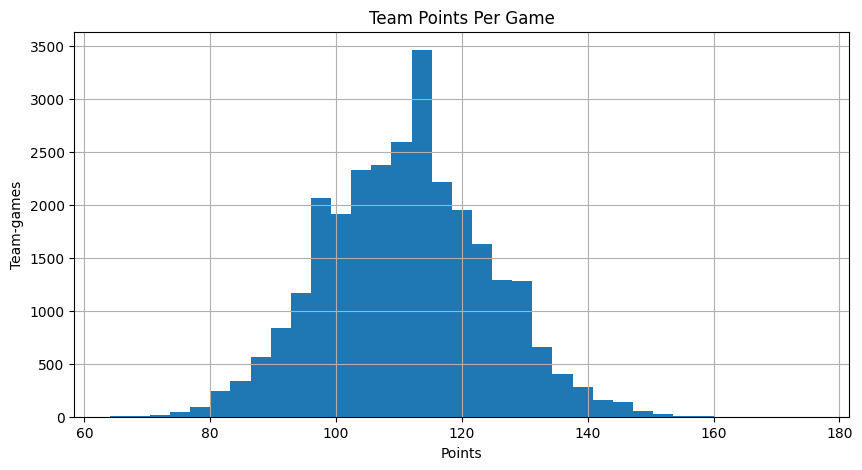

In [6]:
regular = team[team['SEASON_TYPE'].eq('Regular Season')].copy()
regular['GAME_DATE'] = pd.to_datetime(regular['GAME_DATE'])

fig, ax = plt.subplots(figsize=(10, 5))
regular['PTS'].hist(bins=35, ax=ax)
ax.set_title('Team Points Per Game')
ax.set_xlabel('Points')
ax.set_ylabel('Team-games')
plt.show()

## Highest-Scoring Team Snapshot

This final table is a lightweight basketball sanity check: teams with high average points should look plausible, and row counts should be large enough to trust the averages.


In [7]:
team.groupby('TEAM_ABBREVIATION')['PTS'].agg(['count', 'mean', 'std']).sort_values('mean', ascending=False).head(10)

,count,mean,std
TEAM_ABBREVIATION,,,
GSW,1065,114.237559,12.751268
DEN,1036,113.376448,13.425233
OKC,1016,112.500000,13.259517
MIL,1029,112.499514,13.771243
HOU,1003,112.293121,12.756738
ATL,983,112.277721,13.438295
MIN,981,112.220183,12.589615
BOS,1088,111.762868,12.812311
NOP,961,111.720083,12.651157
